<a href="https://colab.research.google.com/github/Padmasriariveni/CustomerChurnPrediction1/blob/main/social_media_addiction_checker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step: 1 Let's import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#load the dataset
df=pd.read_csv("/content/social_media_data.csv")

In [ ]:
df.head()

,daily_usage_hrs,platforms_used,notifications_per_hr,sleep_disruptions,avg_sleep_hrs,missed_classes,gpa,stress_level,mood_score,checks_phone_morning,scrolls_before_sleep,feels_anxious_without,physical_activity_hrs,year_of_study,gender,addiction_level,addiction_label
0,5.5,4,21.5,1,7.5,18,3.75,8,8,1,0,1,2.2,3,Female,2,High
1,4.2,4,25.7,1,5.6,12,3.34,10,4,0,1,1,1.7,2,Female,2,High
2,5.8,3,26.9,1,7.1,12,3.76,2,3,1,0,1,0.5,4,Female,2,High
3,7.5,1,11.2,4,8.3,0,3.46,9,4,0,1,0,1.4,4,Male,1,Medium
4,4.0,6,21.8,0,6.3,1,2.35,1,6,1,0,1,0.0,2,Female,0,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   daily_usage_hrs        1500 non-null   float64
 1   platforms_used         1500 non-null   int64  
 2   notifications_per_hr   1500 non-null   float64
 3   sleep_disruptions      1500 non-null   int64  
 4   avg_sleep_hrs          1500 non-null   float64
 5   missed_classes         1500 non-null   int64  
 6   gpa                    1500 non-null   float64
 7   stress_level           1500 non-null   int64  
 8   mood_score             1500 non-null   int64  
 9   checks_phone_morning   1500 non-null   int64  
 10  scrolls_before_sleep   1500 non-null   int64  
 11  feels_anxious_without  1500 non-null   int64  
 12  physical_activity_hrs  1500 non-null   float64
 13  year_of_study          1500 non-null   int64  
 14  gender                 1500 non-null   object 
 15  addi

In [ ]:
#data cleaning
#fill numerical missing values
for col in df.select_dtypes(include=np.number).columns:
  df[col]=df[col].fillna(df[col].median())

In [ ]:
#fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
daily_usage_hrs,0
platforms_used,0
notifications_per_hr,0
sleep_disruptions,0
avg_sleep_hrs,0
missed_classes,0
gpa,0
stress_level,0
mood_score,0
checks_phone_morning,0


In [ ]:
df.describe()

,daily_usage_hrs,platforms_used,notifications_per_hr,sleep_disruptions,avg_sleep_hrs,missed_classes,gpa,stress_level,mood_score,checks_phone_morning,scrolls_before_sleep,feels_anxious_without,physical_activity_hrs,year_of_study,addiction_level
count,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,4.610867,3.51800,15.050067,3.463333,6.529867,9.549333,2.990833,5.441333,5.430000,0.52600,0.484667,0.508000,1.555800,2.504000,1.010000
std,1.951150,1.69497,7.730394,2.277450,1.172256,5.797411,0.588253,2.900143,2.847192,0.49949,0.499932,0.500103,0.947029,1.116609,0.818747
min,0.500000,1.00000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.300000,2.00000,9.375000,1.000000,5.700000,4.000000,2.587500,3.000000,3.000000,0.00000,0.000000,0.000000,0.875000,2.000000,0.000000
50%,4.600000,4.00000,14.950000,3.000000,6.500000,9.000000,3.000000,5.000000,5.000000,1.00000,0.000000,1.000000,1.600000,2.000000,1.000000
75%,5.900000,5.00000,20.600000,5.000000,7.300000,15.000000,3.420000,8.000000,8.000000,1.00000,1.000000,1.000000,2.200000,4.000000,2.000000
max,12.000000,6.00000,38.400000,7.000000,9.000000,19.000000,4.000000,10.000000,10.000000,1.00000,1.000000,1.000000,4.400000,4.000000,2.000000


In [ ]:
plt.figure(figsize=(14,10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

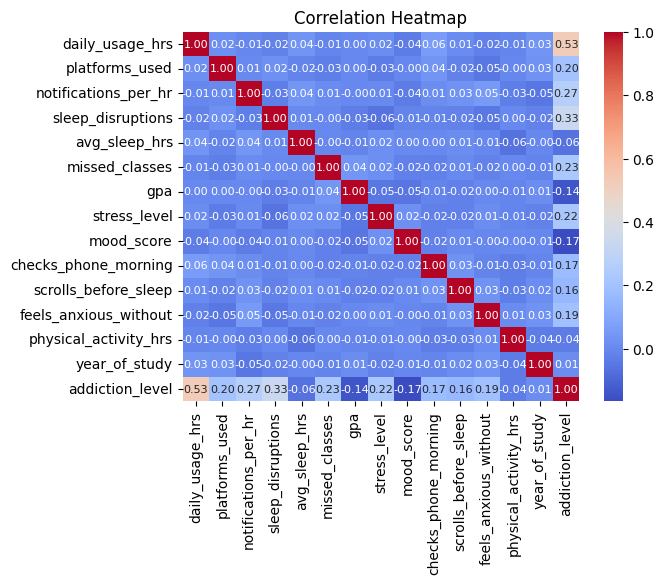

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f",annot_kws={'size':8})
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#encode categorical variables
le=LabelEncoder()

In [ ]:
for col in df.select_dtypes(include="object").columns:
  df[col]=le.fit_transform(df[col])

In [ ]:
X=df.drop(columns=['addiction_label','addiction_level'])
Y=df['addiction_label']

In [ ]:
#Train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
model=RandomForestClassifier(random_state=42)
model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print("\nAccuracy:")
print(accuracy_score(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))



Accuracy:
0.6833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73        90
           1       0.80      0.78      0.79       105
           2       0.55      0.50      0.53       105

    accuracy                           0.68       300
   macro avg       0.68      0.69      0.68       300
weighted avg       0.68      0.68      0.68       300



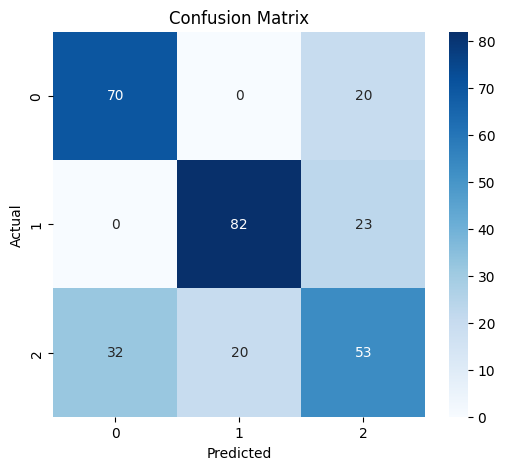

In [ ]:
#Confusion Matrix

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train,Y_train)
y_pred_log=log_model.predict(X_test)

In [ ]:
# Evaluation
print("Logistic Regression Accuracy:")
print(accuracy_score(Y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_log))

Logistic Regression Accuracy:
0.8433333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        90
           1       0.94      0.83      0.88       105
           2       0.77      0.78      0.78       105

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.84      0.84       300



In [ ]:
# Confusion Matrix
cm_log = confusion_matrix(Y_test, y_pred_log)

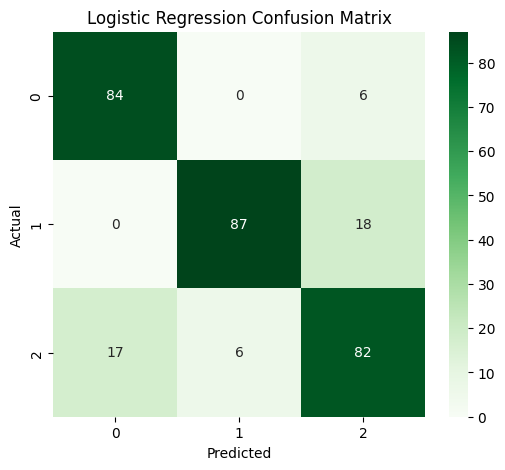

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()